# Loan eligibility prediction 

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import joblib
%matplotlib inline

In [12]:
# import the csv data set
test_Raw_df = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')
train_Raw_df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

In [13]:
test_Raw_df.shape

(367, 12)

In [14]:
train_Raw_df.shape

(614, 13)

In [15]:
# preview the data
test_Raw_df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [16]:
train_Raw_df.head(20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


## Processing the Train data set

In [17]:
train_Raw_df.info()
train_Raw_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [18]:
# filling the missing values 

train_Raw_df['Credit_History'].fillna(0.0,inplace=True)
train_Raw_df['Dependents'].fillna("0", inplace=True)
train_Raw_df['Self_Employed'].fillna('No', inplace=True)
train_Raw_df['LoanAmount'].fillna(
    train_Raw_df['LoanAmount'].mean(), inplace=True)
train_Raw_df['Loan_Amount_Term'].fillna(train_Raw_df['Loan_Amount_Term'].mean(), inplace=True)
train_Raw_df.dropna(subset=['Married'], inplace=True)
train_Raw_df.dropna(subset=['Gender'], inplace=True)

/tmp/ipykernel_267627/361707763.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_Raw_df['Credit_History'].fillna(0.0,inplace=True)
/tmp/ipykernel_267627/361707763.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [19]:
train_Raw_df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [20]:
# 
train_Raw_df.drop(['Loan_ID'], axis=1, inplace=True)

In [21]:
train_Raw_df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.000000,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.000000,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.000000,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.000000,360.0,1.0,Urban,Y


In [22]:
#  convert the categorical data to numerical data
class ToNumerical:
    def __init__(self,):
        pass
    def gender(self,gen):
        if gen =="Male":
            return 1
        else:
            return 0
    def married(self,mar):
        if mar =="Yes":
            return 1
        else:
            return 0
    def education(self,edu):
        if edu =="Graduate":
            return 1
        else:
            return 0
    def employed(self,emp):
        if emp =="Yes":
            return 1
        else:
            return 0
    def property(self,prop):
        if prop =="Semiurban":
            return 1
        elif prop =="Urban":
            return 2
        else:
            return 0
    def loadStatus(self,ls):
        if ls =="Y":
            return 1
        else:
            return 0
    def dependents(self,dep):
        deps = str(dep)
        if '+' in deps:
            return deps.split('+')[0].strip()
        else: return deps.strip()


In [ ]:
#  conventions
toNumerical = ToNumerical()

train_Raw_df['Gender'] = train_Raw_df['Gender'].apply(toNumerical.gender).astype(int)
train_Raw_df['Married'] = train_Raw_df['Married'].apply(toNumerical.married).astype(int)
train_Raw_df['Education'] = train_Raw_df['Education'].apply(
    toNumerical.education).astype(int)
train_Raw_df['Self_Employed'] = train_Raw_df['Self_Employed'].apply(
    toNumerical.employed).astype(int)
train_Raw_df['Property_Area'] = train_Raw_df['Property_Area'].apply(
    toNumerical.property).astype(int)
train_Raw_df['Loan_Status'] = train_Raw_df['Loan_Status'].apply(
    toNumerical.loadStatus).astype(int)
train_Raw_df['Dependents'] = train_Raw_df['Dependents'].apply(toNumerical.dependents).astype(int)
train_Raw_df

In [26]:
train_Raw_df.describe()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000
mean,0.814381,0.648829,0.740803,0.777592,0.130435,5292.252508,1631.499866,145.019491,341.919732,0.774247,1.038462,0.687291
std,0.389124,0.477736,1.003198,0.416212,0.337063,5807.265364,2953.315785,81.236999,64.436901,0.418427,0.789499,0.463985
min,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,1.000000,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,1.000000,0.000000,3806.000000,1211.500000,128.000000,360.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,0.000000,5746.000000,2324.000000,163.500000,360.000000,1.000000,2.000000,1.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000,2.000000,1.000000


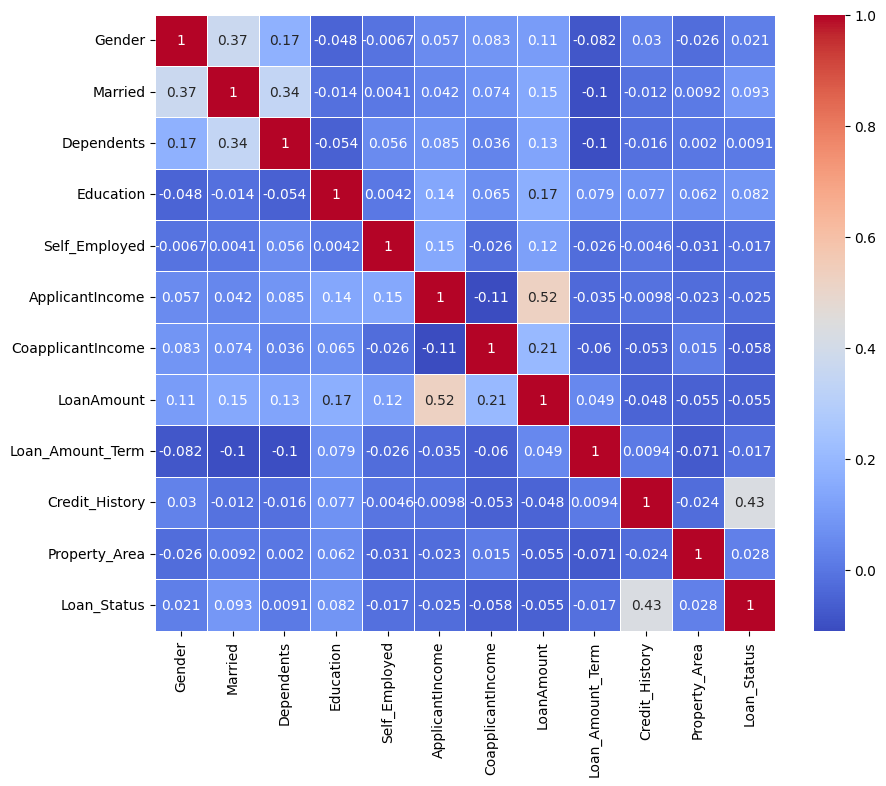

In [ ]:
#  plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(train_Raw_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

In [29]:
X = train_Raw_df.drop('Loan_Status', axis=1)
Y = train_Raw_df['Loan_Status']

## Model Training

In [39]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=42)

In [62]:
#  logistic regression
from sklearn.linear_model import LogisticRegression

modelLG  = LogisticRegression()
modelLG.fit(X_train,Y_train)
YL_pred = modelLG.predict(X_test)
# accuracy = modelLG.score(X_test,Y_test)
# print(f"Accuracy: {round(accuracy*100, 2)}%")


/home/oracle/Documents/Bincom_DataScience/Test/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
# random forest 
from sklearn.ensemble import RandomForestClassifier

modelRFC = RandomForestClassifier()
modelRFC.fit(X_train,Y_train)
YR_pred = modelRFC.predict(X_test)
# accuracy = modelRFC.score(X_test,Y_test)
# print(f"Accuracy: {round(accuracy*100, 2)}%")


## Performance Evaluation

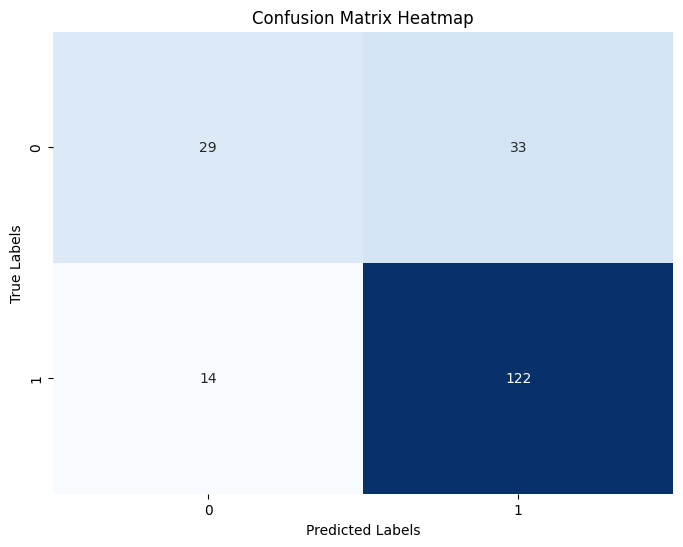

In [ ]:
# confusion matrix of random forest
cmR = confusion_matrix(Y_test, YR_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cmR, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [ ]:

# Accuracy
accuracy = accuracy_score(Y_test, YR_pred)
print(f"Accuracy: {accuracy:.4f}")

# Precision
precisionR = precision_score(Y_test, YR_pred, average='binary')
print(f"Precision: {precisionR:.4f}")

# Recall
recallR = recall_score(Y_test, YR_pred, average='binary')
print(f"Recall: {recallR:.4f}")

# F1 Score
f1R = f1_score(Y_test, YR_pred, average='binary')
print(f"F1 Score: {f1R:.4f}")

Accuracy: 0.7626
Precision: 0.7871
Recall: 0.8971
F1 Score: 0.8385


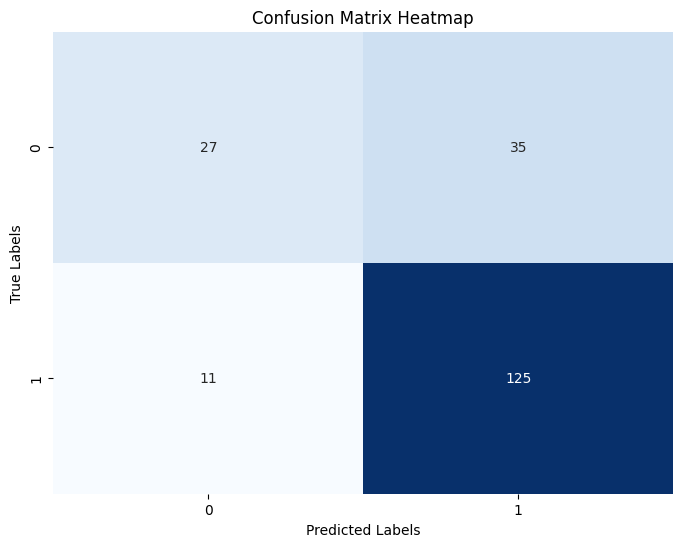

In [65]:
# confusion matrix of logistic regression
cmL = confusion_matrix(Y_test, YL_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cmL, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [66]:

# Accuracy
accuracy = accuracy_score(Y_test, YL_pred)
print(f"Accuracy: {accuracy:.4f}")

# Precision
precisionR = precision_score(Y_test, YL_pred, average='binary')
print(f"Precision: {precisionR:.4f}")

# Recall
recallR = recall_score(Y_test, YL_pred, average='binary')
print(f"Recall: {recallR:.4f}")

# F1 Score
f1R = f1_score(Y_test, YL_pred, average='binary')
print(f"F1 Score: {f1R:.4f}")

Accuracy: 0.7677
Precision: 0.7812
Recall: 0.9191
F1 Score: 0.8446


## Save the models

In [ ]:
# Save the logistic regression model
joblib.dump(modelLG, 'logistic_regression_model.pkl')

# Save the random forest model
joblib.dump(modelRFC, 'random_forest_model.pkl')

['random_forest_model.pkl']

## Usage

In [74]:


class Prediction:
    def __init__(self,data:dict):
        data = list(data.values())
        self.data = data
    def load_model_and_predict_with_LogisticRegression(self):
        # Load the model
        model = joblib.load('logistic_regression_model.pkl')
        # Make prediction
        prediction = model.predict([self.data])
        # Return True if prediction is 1, else False
        return bool(prediction[0])
    
    def load_model_and_predict_with_RandomForest(self):
        # Load the model
        model = joblib.load('random_forest_model.pkl')
        # Make prediction
        prediction = model.predict([self.data])
        # Return True if prediction is 1, else False
        return bool(prediction[0])

# Example usage with data
dummy_data_dict = {
    'Gender': 0,
    'Married': 0,
    'Dependents': 0,
    'Education': 0,
    'Self_Employed': 0,
    'ApplicantIncome': 1000,
    'CoapplicantIncome': 0.0,
    'LoanAmount': 50.0,
    'Loan_Amount_Term': 360.0,
    'Credit_History': 0.0,
    'Property_Area': 0
}
trueDummyData = {
    'Gender': 1,
    'Married': 1,
    'Dependents': 0,
    'Education': 1,
    'Self_Employed': 0,
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 2000.0,
    'LoanAmount': 100.0,
    'Loan_Amount_Term': 360.0,
    'Credit_History': 1.0,
    'Property_Area': 2
}
Prediction = Prediction(trueDummyData)
result_L = Prediction.load_model_and_predict_with_LogisticRegression()
print("LogisticRegressionResult",result_L)
result_R = Prediction.load_model_and_predict_with_RandomForest()
print("RandomForestResult",result_R)

LogisticRegressionResult True
RandomForestResult True


/home/oracle/Documents/Bincom_DataScience/Test/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/oracle/Documents/Bincom_DataScience/Test/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
